In [1]:
from utils.narrative_profiles_optimization_utils import optimise, plot_pareto, plot_best_features
import joblib, pandas as pd
import os
from pathlib import Path






In [2]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.2_narrative_profiles.pkl"
MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)

In [3]:
pipeline = joblib.load(MODEL_PATH)   # your trained Pipeline
X_test   = pd.read_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.2_narrative_profiles_X_test.parquet")

In [9]:
# Metric order returned by the model (same list used during training)
train_metrics = [
    "production_total",
    "emission_total",
    "technical_cost",
    "emission_avg_last_five_years",
]


In [ ]:
# -------------------------------------------------------------
# 1. Single-metric GA  → maximise production_total
# -------------------------------------------------------------
best_x, best_prod = optimise(
    pipeline,
    X_ref=X_test,
    train_targets=train_metrics,
    targets="production_total",     # single metric
    goals="max",                    # “max” or “min”
    n_gen=80,
    pop_size=150,
)

print(f"Best production_total ≈ {best_prod:,.0f}")
print("Optimal feature vector (first 5 cols):\n", best_x.head())

Best production_total ≈ 4,401
Optimal feature vector (first 5 cols):
 group_1_ef_lvst_entferm                            0.388623
group_2_yf_agrc                                    0.983401
group_3_demscalar_soil                             0.095849
group_4_demscalar_ippu                             0.926898
group_5_efficfactor_enfu_industrial_energy_fuel    0.015539
dtype: float64


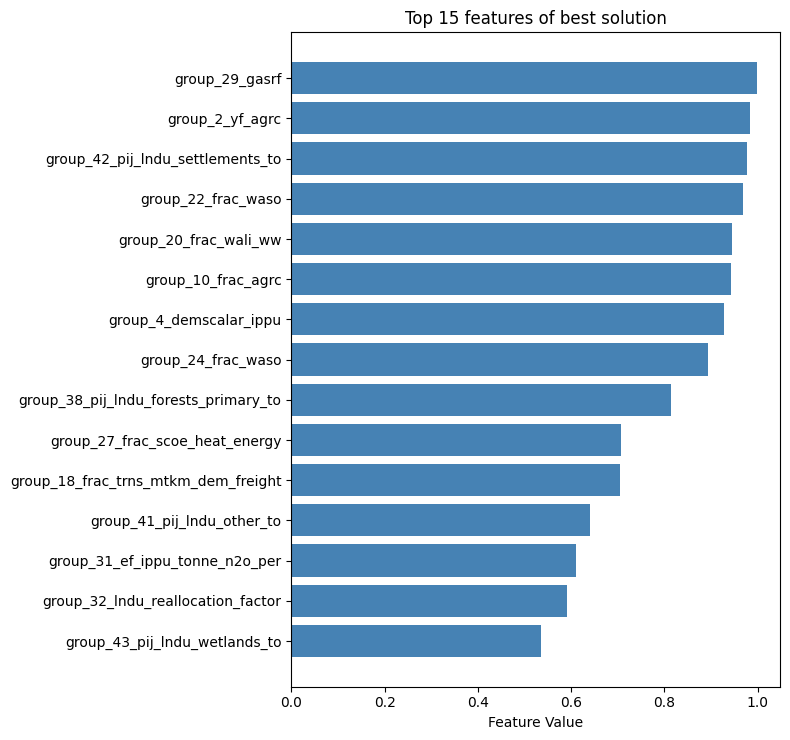

In [11]:
plot_best_features(best_x, top_n=15, title="Top 15 features of best solution")

In [12]:
# -------------------------------------------------------------
# 1. Single-metric GA  → maximise production_total
# -------------------------------------------------------------
best_x_emiss, best_emiss = optimise(
    pipeline,
    X_ref=X_test,
    train_targets=train_metrics,
    targets="emission_total",     # single metric
    goals="min",                    # “max” or “min”
    n_gen=80,
    pop_size=150,
)

print(f"Best emission_total ≈ {best_prod:,.0f}")
print("Optimal feature vector (first 5 cols):\n", best_x.head())

Best emission_total ≈ 4,401
Optimal feature vector (first 5 cols):
 group_1_ef_lvst_entferm                            0.388623
group_2_yf_agrc                                    0.983401
group_3_demscalar_soil                             0.095849
group_4_demscalar_ippu                             0.926898
group_5_efficfactor_enfu_industrial_energy_fuel    0.015539
dtype: float64


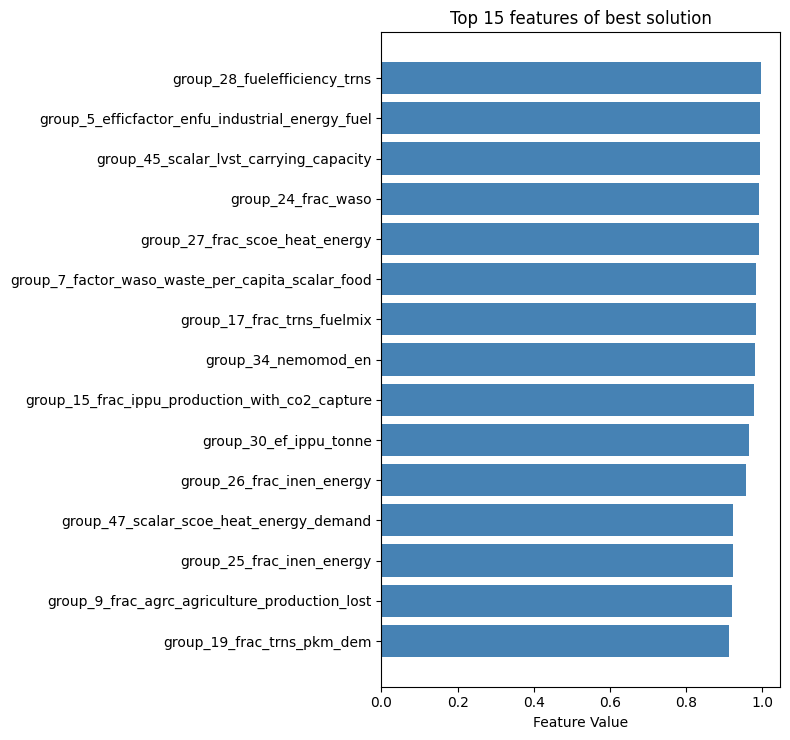

In [13]:
plot_best_features(best_x_emiss, top_n=15, title="Top 15 features of best solution")

In [ ]:
# -------------------------------------------------------------
# 2. Multi-metric NSGA-II  → max prod, min emission + cost
# -------------------------------------------------------------
pareto_X, pareto_F = optimise(
    pipeline,
    X_ref=X_test,
    train_targets=train_metrics,
    targets=["production_total", "emission_total", "technical_cost"],
    goals  =["max",             "min",            "min"],
    n_gen=150,
    pop_size=300,
)


In [ ]:
# -------------------------------------------------------------
# 3. Visualise the Pareto front
# -------------------------------------------------------------
# (a) 3-D scatter for the three chosen metrics
plot_pareto(pareto_F, labels=["Prod", "Emit", "Cost"])

# (b) 2-D slice: production_total vs technical_cost
plot_pareto(pareto_F, cols=["production_total", "technical_cost"])

# (c) Pairwise grid (scatter-matrix) – useful when ≥3 metrics
plot_pareto(pareto_F, pairwise=True)